In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import qiskit
import scipy.linalg as linalg

from qiskit.quantum_info import PauliList, SparsePauliOp, Statevector, Operator, Choi, diamond_norm, process_fidelity, SuperOp
from qiskit import QuantumCircuit

matplotlib.rc('xtick', labelsize=15)
matplotlib.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "Times New Roman"

In [2]:
def get_pauli_sum_op(H):
    """Convert Hamiltonian list to SparsePauliOp."""
    pauli_strings = [term[0] for term in H]
    coeffs = [term[1] for term in H]
    pauli_list = PauliList(pauli_strings)
    return SparsePauliOp(pauli_list, coeffs=coeffs)

In [3]:
def get_exact_unitary(H, t):
    """Compute exact unitary U = exp(-i * H * t)."""
    matrix = get_pauli_sum_op(H).to_matrix()
    return linalg.expm(-1j * matrix * t)

In [4]:
def compute_process_fidelity(Uexact, Uapprox):
    """Compute process fidelity between two unitaries."""
    target = Operator(Uexact)
    channel = SuperOp(Operator(Uapprox))
    return round(process_fidelity(channel, target=target), 4)

In [5]:
def gen_trotter_circuit(H, t, r, sort_type="lex"):
    """Generate a Trotter-Suzuki circuit."""
    pauli_strings = [term[0] for term in H]
    coeffs = [term[1] for term in H]
    nq = len(pauli_strings[0])
    
    if sort_type == "lex":
        sorted_terms = sorted(zip(coeffs, pauli_strings), key=lambda x: x[1])
    elif sort_type == "rand":
        terms = list(zip(coeffs, pauli_strings))
        np.random.shuffle(terms)
        sorted_terms = terms
    else:
        sorted_terms = list(zip(coeffs, pauli_strings))
    
    qc = QuantumCircuit(nq)
    dt = t / r
    
    for _ in range(r):
        for coef, pauli_str in sorted_terms:
            angle = coef * dt
            apply_pauli_expm(qc, pauli_str, angle)
    
    return qc

def apply_pauli_expm(qc, pauli_str, angle):
    """Apply exp(-i * angle * pauli) to circuit."""
    non_id = [(i, p) for i, p in enumerate(pauli_str) if p != "I"]
    
    if not non_id:
        return
    
    qubits = [q for q, p in non_id]
    paulis = [p for q, p in non_id]
    
    for i, p in enumerate(paulis):
        if p == "X":
            qc.h(qubits[i])
        elif p == "Y":
            qc.sdg(qubits[i])
            qc.h(qubits[i])
    
    if len(qubits) > 1:
        for i in range(len(qubits) - 1):
            qc.cx(qubits[i], qubits[i+1])
    
    qc.rz(2 * angle, qubits[-1])
    
    if len(qubits) > 1:
        for i in range(len(qubits) - 2, -1, -1):
            qc.cx(qubits[i], qubits[i+1])
    
    for i, p in enumerate(paulis):
        if p == "X":
            qc.h(qubits[i])
        elif p == "Y":
            qc.h(qubits[i])
            qc.s(qubits[i])

In [6]:
def exact_time_simulation(Hfunc, init_state, meas_op, tstart=0, tend=4, tstep=0.01):
    """Simulate time evolution with exact unitary (no Trotter approximation)."""
    expectations = []
    time = np.arange(tstart, tend, tstep)
    
    for t in time:
        curH = Hfunc(t)
        exact_unitary = get_exact_unitary(curH, t)
        final_state = init_state.evolve(exact_unitary)
        expectations.append(final_state.expectation_value(meas_op).real)
    
    return expectations, time

In [7]:
def trotter_time_simulation(Hfunc, init_state, meas_op, tstart=0, tend=4, tstep=0.01, r=1, sort_type="mc_tsp"):
    """Simulate time evolution with Trotter circuit."""
    expectations = []
    pf_list = []
    time = np.arange(tstart, tend, tstep)
    
    for t in time:
        curH = Hfunc(t)
        
        qc = gen_trotter_circuit(curH, t, r, sort_type)
        evolution_unitary = Operator(qc).data
        
        final_state = init_state.evolve(evolution_unitary)
        expectations.append(final_state.expectation_value(meas_op).real)
        
        exact_unitary = get_exact_unitary(curH, t)
        pf_list.append(compute_process_fidelity(exact_unitary, evolution_unitary))
    
    return expectations, time, pf_list

# Trotterization approximations to Ising Model

In [8]:
nq = 3

def hamiltonian(t):
    omega = np.pi
    epsilon = -1
    interaction = -1
    factor = epsilon * np.cos(omega * t)
    return [('IZZ', interaction), ('ZZI', interaction), ('ZIZ', interaction), 
            ('IIX', factor), ('XII', factor), ('IXI', factor)]

init_circ = QuantumCircuit(nq)
init_state = Statevector.from_instruction(init_circ)
print("Initial state:", init_circ)

meas_op = get_pauli_sum_op([('ZII', 1), ('IZI', 1), ('IIZ', 1)])

# Run exact simulation
print("Exact results...")
exact_expectations, times = exact_time_simulation(hamiltonian, init_state, meas_op, 
                                                  tend=0.5*np.pi, tstep=0.01)
exact_pf = [1.0] * len(times)  # Exact has perfect fidelity with itself

results = [('Exact', exact_expectations, times, exact_pf)]
for sort_type in ['lex', 'mag', 'mc_tsp', 'rand']:
    print(f'{sort_type.upper()} results...')
    exp_vals, time_arr, pf_vals = trotter_time_simulation(
        hamiltonian, init_state, meas_op, tend=0.5*np.pi, tstep=0.01, r=1, sort_type=sort_type)
    results.append((sort_type.upper(), exp_vals, time_arr, pf_vals))
print('done')

Initial state:      
q_0: 
     
q_1: 
     
q_2: 
     
Exact results...
LEX results...
MAG results...
MC_TSP results...
RAND results...
done


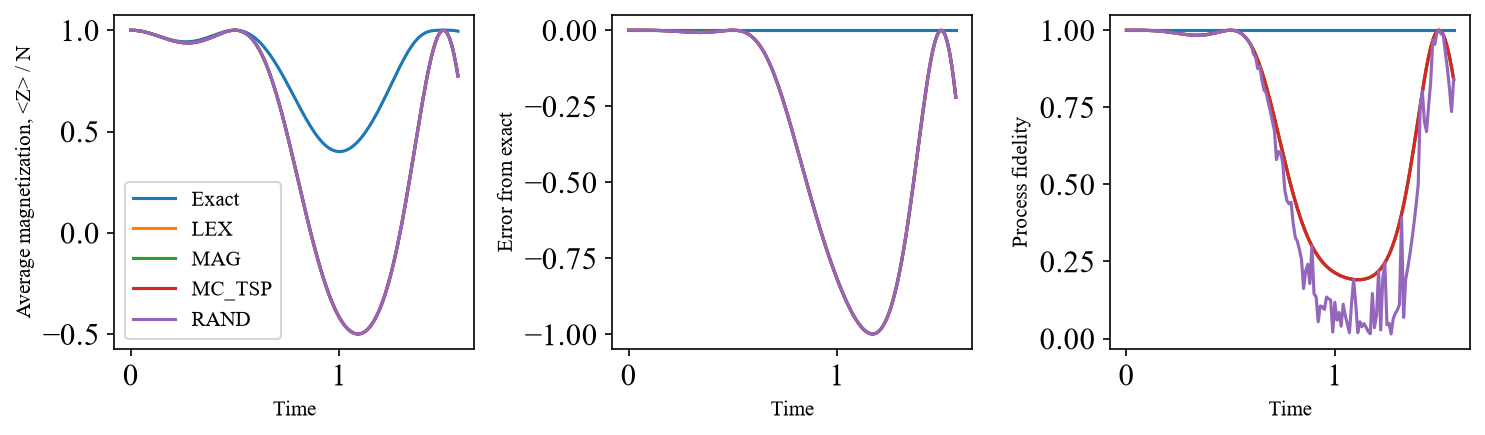

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=3, dpi=150, figsize=[10,3])
exact_results = results[0][1]
for i, (label, expectations, time, pfids) in enumerate(results):
    offset = 0.01 * i * 0
    ax[0].plot(time, [expval / nq + offset for expval in expectations], label=label)
    ax[1].plot(time, [(approx - exact)/ nq for approx, exact in zip(expectations, exact_results)], label=label)
    if pfids:
        ax[2].plot(time, pfids, label=label)
ax[0].legend()
ax[0].set_ylabel('Average magnetization, <Z> / N')
ax[0].set_xlabel('Time')
ax[1].set_ylabel('Error from exact')
ax[1].set_xlabel('Time')
ax[2].set_ylabel('Process fidelity')
ax[2].set_xlabel('Time')
plt.tight_layout()
plt.show()